<img src="images/Project Banner.png" style="max-width:100%; height:auto;">


## Handwritten Digit Recognition Using the MNIST Dataset

### 1.Business Understanding

Project Objective :

This project aims to design and evaluate a supervised machine learning model for handwritten digit recognition using the MNIST dataset. The task is formulated as a multi-class classification problem, where the input consists of 28×28 grayscale images and the output is a digit label from 0 to 9. Model performance is primarily assessed based on classification accuracy on the test set while minimizing overfitting.

### 2.Data Understanding

Dataset Description
The MNIST dataset consists of grayscale handwritten digit images with a resolution of 28×28 pixels, comprising 60,000 training samples and 10,000 test samples.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
import os, random, time
from tensorflow import keras
warnings.filterwarnings("ignore")
from tensorflow.keras import models, layers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



from keras.datasets import mnist


In [5]:
# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [6]:
#Loading MNIST
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [ ]:
print("Train:", train_images.shape, train_labels.shape)
print("Test :", test_images.shape,  test_labels.shape)
print("Pixel range:", train_images.min(), "to", train_images.max())

Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)
Pixel range: 0 to 255


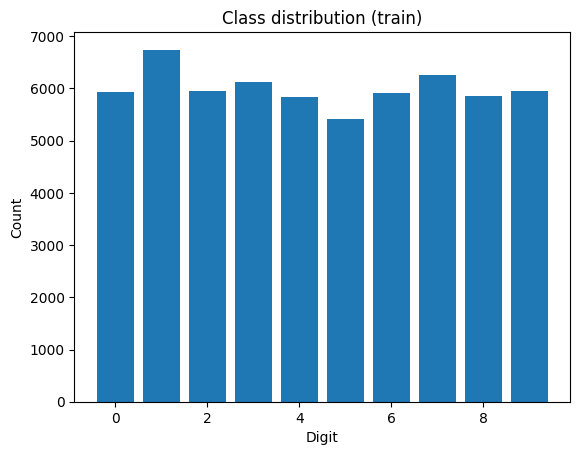

In [9]:
#Class distribution
unique, counts = np.unique(train_labels, return_counts=True)
plt.figure()
plt.bar(unique, counts)
plt.title("Class distribution (train)")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()


The MNIST dataset is approximately balanced, but not perfectly equal

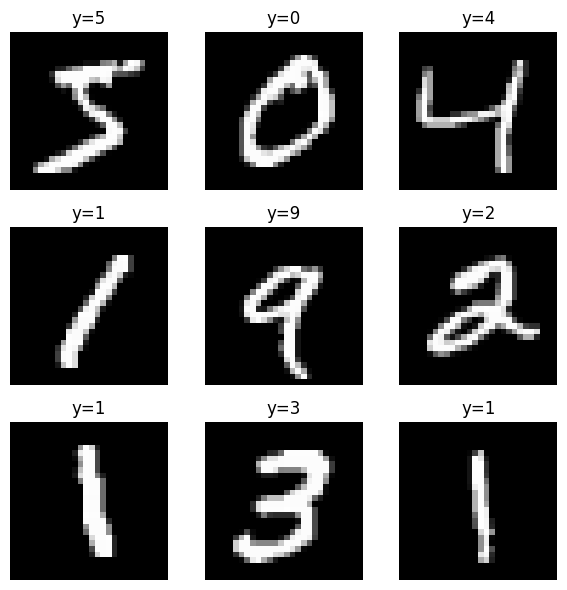

In [10]:
#Display sample images
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(f"y={train_labels[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


### 3.Data Preparation

In [11]:
#Normalization and data type conversion
train_images_f  = train_images.astype("float32") / 255.0
test_images_f   = test_images.astype("float32") / 255.0

# Add channel dim: (N, 28, 28, 1)
train_images_f = train_images_f [..., np.newaxis]
test_images_f  = test_images_f [..., np.newaxis]

print(train_images_f .shape, test_images_f.shape)
 

(60000, 28, 28, 1) (10000, 28, 28, 1)


In [12]:
#One-hot encode labels
train_labels_oh = to_categorical(train_labels, 10)
test_labels_oh  = to_categorical(test_labels, 10)

In [13]:
#Split validation set

X_tr, X_val, y_tr, y_val = train_test_split(
    train_images_f, train_labels_oh, test_size=0.1, random_state=SEED, stratify=train_labels
)


print("Train split:", X_tr.shape, y_tr.shape)
print("Val split  :", X_val.shape, y_val.shape)


Train split: (54000, 28, 28, 1) (54000, 10)
Val split  : (6000, 28, 28, 1) (6000, 10)


### 4.Modeling

In [13]:
# Flatten for sklearn baseline
X_tr_flat = X_tr.reshape(len(X_tr), -1)
y_tr_int  = np.argmax(y_tr, axis=1)

In [14]:
# CNN input shape enforcement (N,28,28,1)
if X_tr.ndim == 3:
    X_tr_cnn = X_tr[..., None]
    X_val_cnn = X_val[..., None]
    test_cnn = test_images_f[..., None]   # used later
else:
    X_tr_cnn, X_val_cnn, test_cnn = X_tr, X_val, test_images_f

In [15]:
# LeNet-5 padding to 32x32
pad = ((0,0), (2,2), (2,2), (0,0))
X_tr_32 = np.pad(X_tr_cnn, pad, mode="constant")
X_val_32 = np.pad(X_val_cnn, pad, mode="constant")
test_32 = np.pad(test_cnn, pad, mode="constant")  # used later

In [16]:
# --- Keras train helper ---
def compile_and_train(model, Xtr, ytr, Xval, yval, epochs=12, batch_size=128):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
    ]
    t0 = time.time()
    history = model.fit(
        Xtr, ytr,
        validation_data=(Xval, yval),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=callbacks
    )
    return history, time.time() - t0

In [17]:
# --- Model builders ---
def build_mlp(input_shape, num_classes=10):
    inp = keras.Input(shape=input_shape)
    x = layers.Flatten()(inp)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="MLP")

def build_lenet5(input_shape, num_classes=10):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv2D(6, 5, padding="valid", activation="tanh")(inp)
    x = layers.AveragePooling2D(pool_size=2, strides=2)(x)
    x = layers.Conv2D(16, 5, padding="valid", activation="tanh")(x)
    x = layers.AveragePooling2D(pool_size=2, strides=2)(x)
    x = layers.Conv2D(120, 5, padding="valid", activation="tanh")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(84, activation="tanh")(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="LeNet-5")

def build_improved_cnn(input_shape, num_classes=10):
    inp = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x) 

    out = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="Improved-CNN")


In [18]:
# ----------------------------
# Train models (ONLY TRAINING)
# ----------------------------
trained = {}      # store trained models
train_meta = {}   # store training time, params, etc.

print("\n[TRAIN] Logistic Regression")
t0 = time.time()
lr = LogisticRegression(max_iter=1000, n_jobs=-1)
lr.fit(X_tr_flat, y_tr_int)
train_meta["Logistic Regression"] = {"Train Time (s)": time.time() - t0, "Params": "N/A"}
trained["Logistic Regression"] = lr

print("\n[TRAIN] MLP")
mlp = build_mlp(input_shape=X_tr_cnn.shape[1:])
_, t_mlp = compile_and_train(mlp, X_tr_cnn, y_tr, X_val_cnn, y_val, epochs=12)
train_meta["MLP"] = {"Train Time (s)": t_mlp, "Params": int(mlp.count_params())}
trained["MLP"] = mlp

print("\n[TRAIN] LeNet-5")
lenet = build_lenet5(input_shape=X_tr_32.shape[1:])
_, t_lenet = compile_and_train(lenet, X_tr_32, y_tr, X_val_32, y_val, epochs=15)
train_meta["LeNet-5"] = {"Train Time (s)": t_lenet, "Params": int(lenet.count_params())}
trained["LeNet-5"] = lenet

print("\n[TRAIN] Improved CNN")
cnn = build_improved_cnn(input_shape=X_tr_cnn.shape[1:])
_, t_cnn = compile_and_train(cnn, X_tr_cnn, y_tr, X_val_cnn, y_val, epochs=12)
train_meta["Improved CNN"] = {"Train Time (s)": t_cnn, "Params": int(cnn.count_params())}
trained["Improved CNN"] = cnn

print("\n✅ Phase 4 complete: Models trained and stored in `trained` dictionary.")


[TRAIN] Logistic Regression

[TRAIN] MLP
Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8955 - loss: 0.3506 - val_accuracy: 0.9497 - val_loss: 0.1662 - learning_rate: 0.0010
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9551 - loss: 0.1472 - val_accuracy: 0.9662 - val_loss: 0.1125 - learning_rate: 0.0010
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9669 - loss: 0.1082 - val_accuracy: 0.9735 - val_loss: 0.0915 - learning_rate: 0.0010
Epoch 4/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9750 - loss: 0.0829 - val_accuracy: 0.9745 - val_loss: 0.0861 - learning_rate: 0.0010
Epoch 5/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9782 - loss: 0.0697 - val_accuracy: 0.9763 - val_loss: 0.0824 - learning_rate: 0.0010
Epoch 6/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9812 - loss: 0.0600 - val_accuracy: 0.9785 - val_loss: 0.0734 - learning_rate: 0.0010
Epoch 7/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms

### 5.Evaluation

In [19]:
# Assumptions (from your notebook):
# test_labels: int labels shape (N,)
# test_images: original 28x28 images for visualization (N,28,28)
# test_cnn: (N,28,28,1)  | test_32: (N,32,32,1) | X_test_flat: (N,784)
# trained: dict of models, e.g. {"Logistic Regression": lr, "MLP": mlp, ...}
# -------------------------------------------------------

def keras_predict_proba(model, X):
    return model.predict(X, verbose=0)

def keras_predict_classes(model, X):
    return np.argmax(keras_predict_proba(model, X), axis=1)

def plot_cm_with_numbers(cm, title):
    plt.figure(figsize=(7,7))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(10)
    plt.xticks(ticks, ticks)
    plt.yticks(ticks, ticks)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    thresh = cm.max() / 2
    for i in range(10):
        for j in range(10):
            plt.text(j, i, str(cm[i, j]),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.show()

def plot_cm_normalized(cm, title):
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(7,7))
    plt.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    plt.title(title + " (Normalized)")
    plt.colorbar()
    ticks = np.arange(10)
    plt.xticks(ticks, ticks)
    plt.yticks(ticks, ticks)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    # show percentages
    for i in range(10):
        for j in range(10):
            plt.text(j, i, f"{cm_norm[i, j]*100:.1f}%",
                     ha="center", va="center",
                     color="white" if cm_norm[i, j] > 0.5 else "black")
    plt.tight_layout()
    plt.show()

def top_confusions(cm, k=10):
    pairs = []
    for i in range(10):
        for j in range(10):
            if i != j and cm[i, j] > 0:
                pairs.append((i, j, cm[i, j]))
    pairs.sort(key=lambda x: x[2], reverse=True)
    return pairs[:k]

def show_misclassified(images_28, y_true, y_pred, conf=None, n=10):
    wrong = np.where(y_true != y_pred)[0]
    if len(wrong) == 0:
        print("No misclassifications found.")
        return

    pick = wrong[:n]
    plt.figure(figsize=(12,4))
    for k, idx in enumerate(pick, start=1):
        plt.subplot(2, 5, k)
        plt.imshow(images_28[idx], cmap="gray")
        title = f"T:{y_true[idx]} P:{y_pred[idx]}"
        if conf is not None:
            title += f" ({conf[idx]*100:.1f}%)"
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def hard_examples(y_true, y_pred, proba, top_n=200):
    """
    Hard examples = either misclassified OR low confidence correct predictions.
    score = confidence of predicted class (lower = harder)
    """
    pred_conf = proba[np.arange(len(proba)), np.argmax(proba, axis=1)]
    is_wrong = (y_true != y_pred)

    # include wrong ones first, then low-confidence correct
    wrong_idx = np.where(is_wrong)[0]
    correct_idx = np.where(~is_wrong)[0]

    # sort correct by ascending confidence (hard correct)
    correct_sorted = correct_idx[np.argsort(pred_conf[correct_idx])]

    # combine: all wrong + hardest correct until reaching top_n
    combined = list(wrong_idx) + list(correct_sorted)
    combined = np.array(combined[:top_n])

    hard_df = pd.DataFrame({
        "index": combined,
        "y_true": y_true[combined],
        "y_pred": y_pred[combined],
        "pred_conf": pred_conf[combined]
    }).sort_values(by=["y_true", "pred_conf"], ascending=[True, True])

    return hard_df, pred_conf


In [20]:
# 1) Evaluate each model (accuracy + cm + top confusions)

all_results = []
model_outputs = {}  # store y_pred, proba, cm

for name, model in trained.items():
    if name == "Logistic Regression":
        # sklearn: use predict_proba if available
        y_pred = model.predict(X_test_flat)
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X_test_flat)
        else:
            proba = None
    elif name == "LeNet-5":
        proba = keras_predict_proba(model, test_32)
        y_pred = np.argmax(proba, axis=1)
    else:  # MLP, Improved CNN
        proba = keras_predict_proba(model, test_cnn)
        y_pred = np.argmax(proba, axis=1)

    acc = accuracy_score(test_labels, y_pred)
    cm = confusion_matrix(test_labels, y_pred)

    all_results.append({"Model": name, "Test Accuracy": acc})
    model_outputs[name] = {"y_pred": y_pred, "proba": proba, "cm": cm}

df = pd.DataFrame(all_results).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
display(df)

best_name = df.loc[0, "Model"]
print(f"Best model (by accuracy): {best_name}")


NameError: name 'X_test_flat' is not defined

In [23]:
# 2) Detailed error analysis for best model
best = model_outputs[best_name]
y_pred_best = best["y_pred"]
cm_best = best["cm"]

print("\nClassification Report (Best Model):")
print(classification_report(test_labels, y_pred_best, digits=4))

plot_cm_with_numbers(cm_best, f"Confusion Matrix - {best_name}")
plot_cm_normalized(cm_best, f"Confusion Matrix - {best_name}")

print("\nTop confusion pairs (True -> Pred):")
pairs = top_confusions(cm_best, k=10)
pairs_df = pd.DataFrame(pairs, columns=["True", "Pred", "Count"])
display(pairs_df)


NameError: name 'best_name' is not defined

In [24]:
# 3) Show misclassified samples + confidenc

if best["proba"] is not None:
    hard_df, pred_conf = hard_examples(test_labels, y_pred_best, best["proba"], top_n=200)
    print("\nHard examples (first 20 rows):")
    display(hard_df.head(20))

    print("\nSample misclassifications (with confidence):")
    show_misclassified(test_images, test_labels, y_pred_best, conf=pred_conf, n=10)

    # Save hard examples indices for next CRISP-DM iteration (Modeling improvements)
    hard_df.to_csv("hard_examples_for_next_iteration.csv", index=False)
    print("\n Saved: hard_examples_for_next_iteration.csv")
else:
    print("\nNo probability output available for this model (cannot compute confidence).")
    show_misclassified(test_images, test_labels, y_pred_best, conf=None, n=10)

NameError: name 'best' is not defined

In [25]:
# 4) Optional (Evaluation-only): Ensemble to reduce misclassification
#     (No training; just average probabilities of deep models)

deep_models = [n for n in trained.keys() if n in ["MLP", "LeNet-5", "Improved CNN"] and model_outputs[n]["proba"] is not None]
if len(deep_models) >= 2:
    probas = []
    for n in deep_models:
        probas.append(model_outputs[n]["proba"])

    ens_proba = np.mean(probas, axis=0)
    ens_pred = np.argmax(ens_proba, axis=1)
    ens_acc = accuracy_score(test_labels, ens_pred)

    print(f"\nEnsemble models: {deep_models}")
    print(f"Ensemble Test Accuracy: {ens_acc:.4f}")

    cm_ens = confusion_matrix(test_labels, ens_pred)
    plot_cm_normalized(cm_ens, "Confusion Matrix - Ensemble (Normalized)")

    # Compare misclassification count best vs ensemble
    best_mis = np.sum(test_labels != y_pred_best)
    ens_mis = np.sum(test_labels != ens_pred)
    print(f"Misclassifications - Best: {best_mis} | Ensemble: {ens_mis} | Reduced by: {best_mis - ens_mis}")
else:
    print("\nEnsemble skipped (need at least 2 deep models with probability outputs).")

KeyError: 'MLP'

### 6.Deployment